# Execute the code below

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px

df_weather = pd.read_csv("../Data/weather2019.csv")

# Multivariate linear regression with Scikit-Learn

The equation of an univariate linear regresion is a line : aX +b

The equation of a multivariate linear regression with 2 variables is a plan : aW + bX + c

The equation of a multivariate linear regression with n variables is a hyperplan : a1 X1 + a2 X2 + .... + an Xn + b


## Let's start with 2 variables
With Plotly express, show a [3D scatterplot ](https://plotly.com/python/plotly-express/#3d-coordinates)with :
- X-axis : MAX temperature
- Y-axis : MIN temperature
- Z-axis : Sunhours


In [2]:
# Complete x, y and z in the script below:
px.scatter_3d(x = "MAX_TEMPERATURE_C",
              y = "MIN_TEMPERATURE_C",
              z = "SUNHOUR",
              data_frame=df_weather)


Is it hard to read the 3D scatterplot ? You can move it with your mouse.

### Let's predict
You have to predict the MAX temperature from 2 variables :
- MIN temperature
- Sunhours

Hey, it's the reason why X has 2 brackets and is uppercase and y has a simple bracket and is lowercase . It can take multiple variables (X) to predict only one target (y).

**Remember to save the result of your prediction in a new column 'predict'.**

In [3]:
# Your code here :

from sklearn.linear_model import LinearRegression
X = df_weather[['MIN_TEMPERATURE_C', 'SUNHOUR']]
y = df_weather['MAX_TEMPERATURE_C']

# We train a "model" with "fit" function. This model will store coefficients after training.
model = LinearRegression().fit(X, y)

In [4]:
# Coefficient, it's the "a" in your equation "aX + b"
print("coefficient :",model.coef_)

# Interception, it's the "b" in your equation "aX + b"
print("intercept :", model.intercept_)


coefficient : [0.98867383 0.66222402]
intercept : 1.6488837312596853


In [5]:
# prediction of one value :
print("Scikit-Learn :  ", model.predict([[10, 5]])  )

Scikit-Learn :   [14.8467421]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



In [6]:
# prediction of several values and adding of a new column 'predict' :
df_weather['predict'] = model.predict(X)

# you can check that predict columns has been added :
df_weather.info()
df_weather.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   DATE                    365 non-null    object 
 1   MAX_TEMPERATURE_C       365 non-null    int64  
 2   MIN_TEMPERATURE_C       365 non-null    int64  
 3   WINDSPEED_MAX_KMH       365 non-null    int64  
 4   TEMPERATURE_MORNING_C   365 non-null    int64  
 5   TEMPERATURE_NOON_C      365 non-null    int64  
 6   TEMPERATURE_EVENING_C   365 non-null    int64  
 7   PRECIP_TOTAL_DAY_MM     365 non-null    float64
 8   HUMIDITY_MAX_PERCENT    365 non-null    int64  
 9   VISIBILITY_AVG_KM       365 non-null    float64
 10  PRESSURE_MAX_MB         365 non-null    int64  
 11  CLOUDCOVER_AVG_PERCENT  365 non-null    float64
 12  HEATINDEX_MAX_C         365 non-null    int64  
 13  DEWPOINT_MAX_C          365 non-null    int64  
 14  WINDTEMP_MAX_C          365 non-null    in

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C,TEMPERATURE_NOON_C,TEMPERATURE_EVENING_C,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WEATHER_CODE_MORNING,WEATHER_CODE_NOON,WEATHER_CODE_EVENING,TOTAL_SNOW_MM,UV_INDEX,SUNHOUR,OPINION,MONTH,DAY,predict
0,2019-01-01,9,4,10,4,7,8,0.2,94,9.0,...,116,143,176,0,1,5.1,very bad,1,1,8.980922
1,2019-01-02,8,5,18,7,7,5,0.0,90,9.0,...,119,116,116,0,1,8.7,very bad,1,2,12.353602
2,2019-01-03,6,0,18,0,4,3,0.0,88,10.0,...,116,116,116,0,1,8.7,very bad,1,3,7.410233
3,2019-01-04,5,-1,15,-1,4,3,0.0,91,10.0,...,116,116,122,0,1,5.1,very bad,1,4,4.037552
4,2019-01-05,6,-1,8,-1,4,3,0.0,91,8.0,...,143,116,116,0,1,8.7,very bad,1,5,6.421559


### Let's visualize
With Plotly express, show a 3D scatterplot with :

- X-axis : your new 'predict' column
- Y-axis : MIN temperature
- Z-axis : Sunhours



In [7]:
# Your code here :
px.scatter_3d(data_frame = df_weather,
              x = 'predict',
              y = 'MIN_TEMPERATURE_C',
              z = 'SUNHOUR')

**Move the cube with your mouse. Hey your 3D-scatterplot has a special shape : it's a plan !**

## Multivariate linear regressions with N-variables
Make a prediction with the maximum number of variables. But beware :
- variables must be numeric
- your target (MAX temperature) should not be present in variables

Store your prediction in a new column 'predict2'.

In our 3D human vision, we can't represent a hyperplan. But, let's trust in our computer, it can calculate. So trust it and show a simple scatterplot with :
- X-axis : Date
- Y-axis : MAX temperatures in blue dots and 'predict2' in orange dots

Expected result:

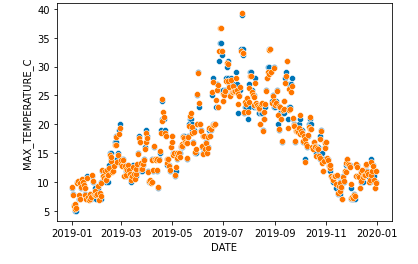

In [9]:
# you can automatically select all the numeric columns with a select_dtypes and drop the target column :
df_weather.select_dtypes(include = 'number').drop(columns='MAX_TEMPERATURE_C')

,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C,TEMPERATURE_NOON_C,TEMPERATURE_EVENING_C,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,PRESSURE_MAX_MB,CLOUDCOVER_AVG_PERCENT,...,WINDTEMP_MAX_C,WEATHER_CODE_MORNING,WEATHER_CODE_NOON,WEATHER_CODE_EVENING,TOTAL_SNOW_MM,UV_INDEX,SUNHOUR,MONTH,DAY,predict
0,4,10,4,7,8,0.2,94,9.000,1037,62.250,...,3,116,143,176,0,1,5.1,1,1,8.980922
1,5,18,7,7,5,0.0,90,9.000,1040,58.125,...,3,119,116,116,0,1,8.7,1,2,12.353602
2,0,18,0,4,3,0.0,88,10.000,1040,37.000,...,-4,116,116,116,0,1,8.7,1,3,7.410233
3,-1,15,-1,4,3,0.0,91,10.000,1040,42.625,...,-4,116,116,122,0,1,5.1,1,4,4.037552
4,-1,8,-1,4,3,0.0,91,8.000,1040,17.250,...,-2,143,116,116,0,1,8.7,1,5,6.421559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
360,10,13,10,12,11,0.0,96,7.375,1033,57.625,...,8,119,143,116,0,1,8.7,12,27,17.296971
361,5,12,7,8,8,0.0,93,7.625,1035,39.500,...,4,143,116,116,0,1,6.9,12,28,11.161599
362,2,11,3,6,7,0.0,86,10.000,1034,4.000,...,0,116,116,116,0,1,8.7,12,29,9.387580
363,4,7,5,9,9,0.0,61,10.000,1033,1.875,...,4,113,113,113,0,1,8.7,12,30,11.364928


In [10]:
# define variables and target :

X2 = df_weather.select_dtypes(include = 'number').drop(columns='MAX_TEMPERATURE_C')
y2 = df_weather['MAX_TEMPERATURE_C']

# train the model :

model2 = LinearRegression().fit(X2, y2)

In [11]:
# ajout de la colonne avec les predictions :
df_weather['predict2'] = model2.predict(X2)

df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   DATE                    365 non-null    object 
 1   MAX_TEMPERATURE_C       365 non-null    int64  
 2   MIN_TEMPERATURE_C       365 non-null    int64  
 3   WINDSPEED_MAX_KMH       365 non-null    int64  
 4   TEMPERATURE_MORNING_C   365 non-null    int64  
 5   TEMPERATURE_NOON_C      365 non-null    int64  
 6   TEMPERATURE_EVENING_C   365 non-null    int64  
 7   PRECIP_TOTAL_DAY_MM     365 non-null    float64
 8   HUMIDITY_MAX_PERCENT    365 non-null    int64  
 9   VISIBILITY_AVG_KM       365 non-null    float64
 10  PRESSURE_MAX_MB         365 non-null    int64  
 11  CLOUDCOVER_AVG_PERCENT  365 non-null    float64
 12  HEATINDEX_MAX_C         365 non-null    int64  
 13  DEWPOINT_MAX_C          365 non-null    int64  
 14  WINDTEMP_MAX_C          365 non-null    in

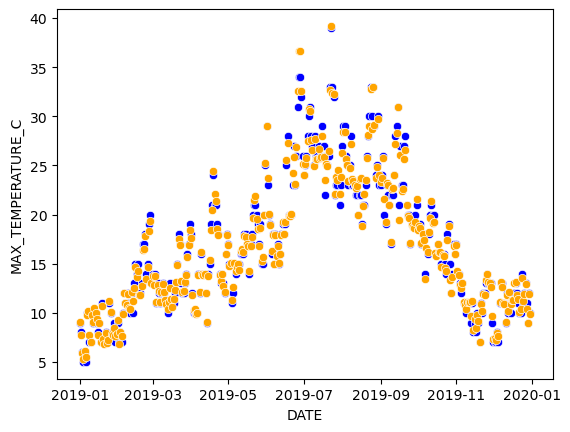

In [12]:
# convert DATE column into datetime format so it can be used in our graph
df_weather['DATE'] = pd.to_datetime(df_weather['DATE'])

# creation of two scatterplot one with real Max Temperature C and one with our prediction
sns.scatterplot(data = df_weather,
                x = 'DATE',
                y = 'MAX_TEMPERATURE_C',
                color = 'blue')

sns.scatterplot(data = df_weather,
                x = 'DATE',
                y = 'predict2',
                color = 'orange')

plt.show()

You can read coefficient for each column with the attribute `.coef_`. Which column has the biggest coefficient ?

In [36]:
# you can look at the max coefficient directly by reading all the results :


column_coefs = list(zip(X2.columns, model2.coef_))

# sorted(column_coefs, key=lambda x: x[1])
column_coefs.sort(key=lambda x: x[1], reverse=True)
column_coefs

[('HEATINDEX_MAX_C', 0.5842807479084094),
 ('TEMPERATURE_NOON_C', 0.1910416471108986),
 ('TEMPERATURE_EVENING_C', 0.17694033106464763),
 ('WINDTEMP_MAX_C', 0.05221594780581032),
 ('MIN_TEMPERATURE_C', 0.041269226496699965),
 ('predict', 0.0204019615691621),
 ('MONTH', 0.010717391001480003),
 ('VISIBILITY_AVG_KM', 0.010042909338621172),
 ('PRECIP_TOTAL_DAY_MM', 0.0050483426120743816),
 ('WEATHER_CODE_MORNING', 0.00052991465867637),
 ('WEATHER_CODE_NOON', 9.325673998718118e-05),
 ('TOTAL_SNOW_MM', 2.7755575615628914e-17),
 ('WEATHER_CODE_EVENING', -0.00021177678205343308),
 ('PRESSURE_MAX_MB', -0.000583380423385681),
 ('DAY', -0.0013309235416139758),
 ('HUMIDITY_MAX_PERCENT', -0.002528887177831933),
 ('WINDSPEED_MAX_KMH', -0.0028239283637970175),
 ('CLOUDCOVER_AVG_PERCENT', -0.005793786341190898),
 ('UV_INDEX', -0.02829646663345598),
 ('SUNHOUR', -0.030805047736161585),
 ('DEWPOINT_MAX_C', -0.03418089114194287),
 ('TEMPERATURE_MORNING_C', -0.0877957991658936)]

In [34]:
# passing the list into a dataframe

# sort it by coef value and by descending order and show only its first row
df_name_coeff = pd.DataFrame(column_coefs, columns = ['X2.columns', 'model2.coef_'])
# df_name_coeff.sort_values(by = 'model2.coef_', ascending = False, inplace=True)
df_name_coeff

,X2.columns,model2.coef_
0,HEATINDEX_MAX_C,5.842807e-01
1,TEMPERATURE_NOON_C,1.910416e-01
2,TEMPERATURE_EVENING_C,1.769403e-01
3,WINDTEMP_MAX_C,5.221595e-02
4,MIN_TEMPERATURE_C,4.126923e-02
5,predict,2.040196e-02
6,MONTH,1.071739e-02
7,VISIBILITY_AVG_KM,1.004291e-02
8,PRECIP_TOTAL_DAY_MM,5.048343e-03
9,WEATHER_CODE_MORNING,5.299147e-04


In [16]:
df_name_coeff.head(1)

,X2.columns,model2.coef_
10,HEATINDEX_MAX_C,0.584281


In [17]:
# or use idxmax to find the index number where the maximum value in column model2.coef_ is (idxmax)
# and looking for this row in the dataframe df_name_coeff (iloc)

max_coeff = df_name_coeff.loc[df_name_coeff['model2.coef_'].idxmax()].values
max_coeff

array(['HEATINDEX_MAX_C', 0.5842807479084094], dtype=object)

In [18]:
print(f'Maximum coefficient is {round(max_coeff[1], 2)}, for column {max_coeff[0]}')

Maximum coefficient is 0.58, for column HEATINDEX_MAX_C


### To evaluate the model more precisely

In [ ]:
model2.score(X2, y2) # r_squared

Don't hesitate to try different combinations of features, and to use plots and the `score` method to see how your model is changing with the addition of new features.